## 1. Image-PCD Variational Autoencoder
$img+pcd \Rightarrow latent$

<u>Available models:</u>
- VAE

(19999, 8)


Text(0.5, 0, 'Epoch')

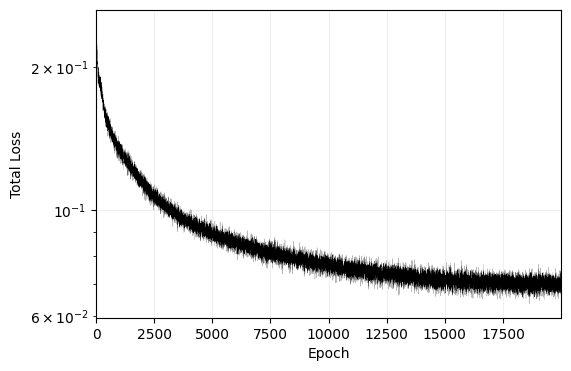

In [1]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt

model = '1_model'
alias = '0411_combined'
alias = '0414'

loss_logs = pd.read_csv(f'../../../../scratch/btuncay/cog/gnn_spatial_reasoning/{model}/{alias}/losses.csv')
loss_logs = loss_logs.to_numpy()
print(loss_logs.shape)
plt.figure(figsize=(6,4))
plt.plot(loss_logs[:,0],loss_logs[:,1],'k',linewidth=0.1)
plt.xlim(0,loss_logs.shape[0])
plt.grid(alpha=0.2)
plt.yscale('log')
plt.ylabel('Total Loss')
plt.xlabel('Epoch')
#plt.savefig(f'figures/autoencoder_loss_{alias}.svg')

## 2. Translation Prediction 
$latent \Leftrightarrow latent$

<u>Available models:</u>
- Pairwise MLP
- **Transformer**

(617, 30)
Best epoch: 204


Text(0.5, 0, 'Epoch')

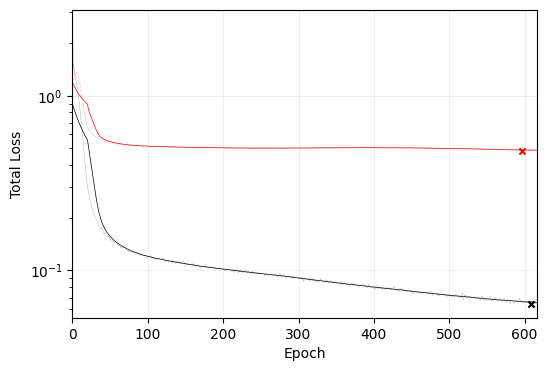

In [3]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt

model = '2_model_movement'
alias = '0510_gnn_k2_edge_l1'
alias = '0510_gnn_k2'
alias = '0511_lstm' #traj.loss min 1.4
alias = '0511_lstm_l2' #traj.loss min 1.4
alias = '0511_gnn_k1_edge_l1'
alias = '0511_pair_mlp_k2'
alias = '0511_gnn_k1_l4'
alias = '0511_gnn_k1_edge_l2'
alias = '0511_gnn_k1_l2_d32'
alias = '0511_gnn_k1_edge_l3'
alias = '0511_gnn_k1_l2_d16' #latest fixed angle loss [4:5]
alias = '0512_gnn_k1_l2_d16' #tanh activation
alias = '0511_gnn_k1_l2'
alias = '0512_gru_stable' #gru model
alias = '0512_gnn_k1_l2_d16_vel' #momentum loss
alias = '0512_gnn_k1_l2_d16_div' #edge attr: dst/src; tanh activation
alias = '0513_gnn_k1_l12_d16_vel' #updated momentum loss, tanh
alias = '0513_gnn_k2_l12_d16_vel' #updated momentum loss, tanh
alias = '0513_gnn_k2_l2_d16_vel' #updated momentum loss, tanh
alias = '0513_gnn_k1_l2_d16_vel' #updated momentum loss, tanh
alias = '0515_gnn_k2_l16_d16_base_yaw' #updated yaw losses - no edge update
alias = '0515_gnn_k2_l16_d16_edge_yaw' #updated yaw losses - edge update
alias = '0515_gnn_k2_l12_d16_edge_yaw' #updated yaw losses - edge update
alias = '0516_gnn_k2_l2_d32_edge_yaw'
alias = '0516_gnn_k2_l2_d16_edge_yaw'
alias = '0516_gnn_k2_l2_d16_base_yaw'
alias = '0517_gnn_k2_l2_d16_anglediff'
alias = '0517_gnn_k2_l1_d16_anglediff'
alias = '0518_gnn_k2_l2_d16_flow'
alias = '0518_gnn_k2_l2_d32_flow'
alias = '0518_gnn_k2_l2_d16_anglediff'
alias = '0518_gnn_k2_l2_d32-16_encoder'
alias = '0519_gnn_k2_l2_d32_encoder_s16' #long rollout; columns: 10-4-13
alias = '0519_gnn_k2_l2_d32_encoder' #2 gnn layers; columns: 10-4-13
alias = '0519_gnn_k2_l8_d32_flow' #deep gnn; columns: 9-4-12
alias = '0519_gnn_k2_l1_d32_flow' #columns: 9-4-12
alias = '0520_gnn_k2_l2_d64_anglediff_yawonly' #angle-only, gelu; columns: 9-4-12
alias = '0520_gnn_k2_l2_d64_anglediff_translation' #translation-only, gelu; columns: 9-4-12
alias = '0520_gnn_k1_l2_d64_anglediff_translation' #translation-only, gelu; columns: 9-4-12
alias = '0520_gnn_k1_l1_d64_anglediff_yawonly' #angle-only, gelu; columns: 9-4-12
alias = '0520_gnn_k1_l2_d64_anglediff_yawonly' #angle-only, gelu; columns: 9-4-12
alias = '0519_gnn_k2_l2_d64_anglediff_gelu' #64d gnn, clean data, mse tr. loss, gelu; columns: 9-4-12
alias = '0519_gnn_k2_l2_d64_anglediff' #64d gnn, clean data, mse tr. loss, tanh; columns: 9-4-12
alias = '0520_gnn_k1_l1_d64_anglediff_translation' #translation-only, gelu; columns: 9-4-12
alias = '0520_gnn_k1_l0_d64_anglediff_translation' #translation-only, gelu; columns: 9-4-12
alias = '0520_gnn_k1_l0_d64_anglediff_yawonly' #angle-only, gelu; columns: 9-4-12
alias = '0519_gnn_k2_l2_d32_encoder_s12' #clean data, mse translation loss; columns: 10-4-13
alias = '0520_gnn_k2_l2_d32_encoder_img' #from-scratch encoder; mse translation loss; columns: 11-4-14
alias = '0521_gnn_k2_l2_d32_flow' #columns: 9-4-12
alias = '0521_gnn_k1_l0_d64_anglediff_translation' #columns: 9-4-12
alias = '0521_gnn_k2_l2_d64_anglediff_gelu' #columns: 9-4-12
alias = '0521_gnn_k2_l2_d64_anglediff_depthprior_sceneholdout' #columns: 9-5-15
alias = '0521_gnn_k2_l2_d64_anglediff_depthprior_relative_sceneholdout' #columns: 9-5-15
alias = '0521_gnn_k2_l2_d64_anglediff_depthprior' #columns: 9-5-15
alias = '0521_gnn_k2_l1_d128_encoder_img' #from-scratch encoder; columns: 10-4-13
alias = '0525_gnn_k2_l2_d128_anglediff_depth' #re-encoded pcd; columns: 9-4-12
alias = '0525_gnn_k2_l2_d32_anglediff_depth' #re-encoded pcd; columns: 9-4-12
alias = '0525_gnn_k2_l2_d32_anglediff_depth_scene' #scene holdout; columns: 9-4-12
alias = '0525_gnn_k2_l2_d32_anglediff_depth_rel' #relative edges only; columns: 9-4-12
alias = '0526_gnn_k2_l2_d32_anglediff_depth_rel' #relative edges only; columns: 9-4-12
alias = '0526_gnn_k2_l2_d32_anglediff_depth_scene_rel' #relative edges only; columns: 9-4-12
#TODO: try with pure rotation or pure translation
val_loss_col = 9
train_col = 4
val_col = 12
k = 20

loss_logs = pd.read_csv(f'../../../../scratch/btuncay/cog/gnn_spatial_reasoning/{model}/{alias}/losses.csv')
loss_logs = loss_logs.to_numpy()
print(loss_logs.shape)
plt.figure(figsize=(6,4))
plt.plot(loss_logs[:,0],loss_logs[:,train_col],'k',linewidth=0.1)
plt.plot(loss_logs[:,0],loss_logs[:,val_col],'r',linewidth=0.1)
mov_avg = [loss_logs[np.arange(max(0,i-k),min(i+k,loss_logs.shape[0]-1)),train_col].mean() for i in range(loss_logs.shape[0])]
mov_avg_val = [loss_logs[np.arange(max(0,i-k),min(i+k,loss_logs.shape[0]-1)),val_col].mean() for i in range(loss_logs.shape[0])]
plt.plot(loss_logs[:,0],mov_avg,'k',linewidth=0.5)
plt.plot(loss_logs[:,0],mov_avg_val,'r',linewidth=0.5)
plt.scatter(loss_logs[loss_logs[:,train_col].argmin(),0],loss_logs[loss_logs[:,train_col].argmin(),train_col],s=20,c='k',marker='x')
plt.scatter(loss_logs[loss_logs[:,val_col].argmin(),0],loss_logs[loss_logs[:,val_col].argmin(),val_col],c='r',s=20,marker='x')
plt.xlim(0,loss_logs.shape[0])
plt.grid(alpha=0.2)
print(f'Best epoch: {loss_logs[:,val_loss_col].argmin()}')
plt.yscale('log')
plt.ylabel('Total Loss')
plt.xlabel('Epoch')

In [6]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt

model = '3_model_recon'
alias = '0417'

loss_logs = pd.read_csv(f'../../../../scratch/btuncay/cog/gnn_spatial_reasoning/{model}/{alias}/losses.csv')
loss_logs = loss_logs.to_numpy()
print(loss_logs.shape)
plt.figure(figsize=(6,4))
plt.plot(loss_logs[:,0],loss_logs[:,3],'k',linewidth=0.1)
plt.xlim(0,loss_logs.shape[0])
plt.grid(alpha=0.2)
plt.yscale('log')
plt.ylabel('Total Loss')
plt.xlabel('Epoch')

FileNotFoundError: [Errno 2] No such file or directory: '../../../../scratch/btuncay/cog/gnn_spatial_reasoning/3_model_recon/0417/losses.csv'

## 4. Point Cloud Localization
$latent \Leftrightarrow latent$

<u>Available models:</u>
- Pairwise MLP

(466, 6)


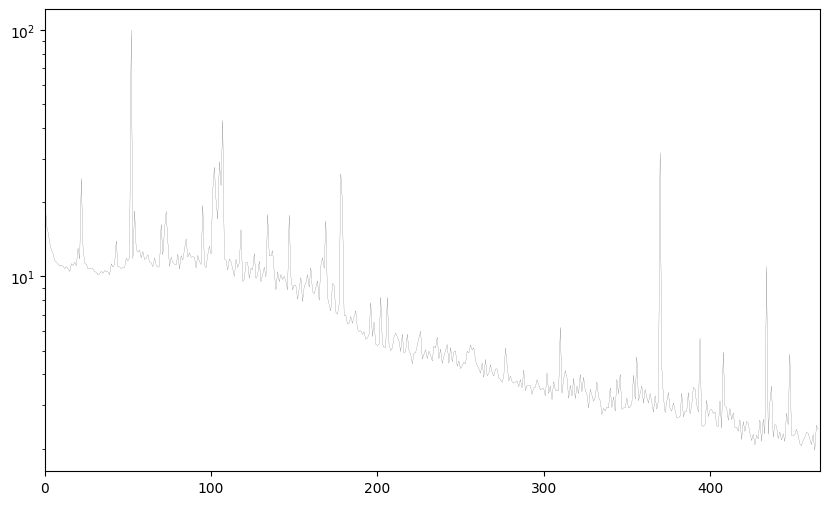

In [1]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt

model = '4_model_locator'
alias = '0414_weighted'
alias = '0414_view_only'
alias = '0415_topk'

loss_logs = pd.read_csv(f'../../../../scratch/btuncay/cog/gnn_spatial_reasoning/{model}/{alias}/losses.csv')
loss_logs = loss_logs.to_numpy()
print(loss_logs.shape)
plt.figure(figsize=(10,6))
plt.plot(loss_logs[:,0],loss_logs[:,1],'k',linewidth=0.1)
#plt.plot(loss_logs[:,0],loss_logs[:,3],'r',linewidth=0.1)
plt.xlim(0,loss_logs.shape[0])
plt.yscale('log')